In [ ]:

options(future.globals.maxSize = 100000000 * 1024^2)
# set random seed for reproducibility
set.seed(12345)
# ========================= Libraries ===================================
# ## We load the required packages
library(dplyr)
library(Seurat)
library(readr)
library(readr)
library(gplots)

# single-cell analysis package
# plotting and data science packages
# library(tidyverse)
library(cowplot)
library(patchwork)
library(RColorBrewer)
library(SingleCellExperiment)
library(dreamlet)
# co-expression network analysis packages:
library(igraph)
library(dittoSeq)
library(scCustomize)


# plotting
library(ggplot2)
library(dplyr)
library(RColorBrewer)
library(cowplot)
library(ggtree)
library(aplot)
library(circlize)
library(ComplexHeatmap)

# meta
library(tidyr)
library(muscat)
library(broom)
library(tidyverse)
library(metafor) 

# library(UCell)
library(Nebulosa)
'%notin%' <- Negate('%in%')
colors <- brewer.pal(n = 9, name = 'Set3')
colors[2] <- colors[8]
colors[8] <- "azure3"

cols_enrich <- c('white','red4')
gmt_list <- c('h.all.v2023.1',
    'c5.go.bp.v2023.1',
    'c5.go.mf.v2023.1',
    'c7.immunesigdb.v2023.1',
    'c7.all.v2023.1',
    "c8.all.v2023.1",
    'c2.cp.kegg.v2023.1',
    'c2.cp.reactome.v2023.1')



source('utils.R')

In [3]:
library(dreamlet)

In [4]:
sessionInfo()

R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 21.04

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
[1] C

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] grid      stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] Nebulosa_1.10.0             metafor_4.2-0              
 [3] numDeriv_2016.8-1.1         metadat_1.2-0              
 [5] Matrix_1.5-4.1              lubridate_1.9.2            
 [7] forcats_1.0.0               stringr_1.5.0              
 [9] purrr_1.0.1                 tibble_3.2.1               
[11] tidyverse_2.0.0             broom_1.0.5                
[13] muscat_1.14.0               tidyr_1.3.0                
[15] ComplexHeatmap_2.16.0       circlize_0.4.15            
[17] aplot_0.1.10                ggtree_3.8.0  

In [2]:
Immune <- readCRDS('')


In [4]:
table(Immune$CellType)


B Cells    MONO Myeloid    NEUT T Cells 
    604    4516   83519    1189    3550 

In [5]:
Microglia_only <- subset(Immune,subset=CellPop %in% c('Myeloid'))

In [6]:
csv_input <- '5.FreshMG_Mapping/MG_predictions_subtype_ADAM.csv'

predictions <- as.data.frame(readr::read_csv(csv_input))
rownames(predictions) <- predictions[,1]
predictions[,1] <- NULL
predictions <- as.data.frame(predictions)[,c('predictions_subtype','predictions_subclass')]
colnames(predictions) <- c('pred_subtype','pred_subclass')
Microglia_only@meta.data <- as.data.frame(cbind(Microglia_only@meta.data,predictions[colnames(Microglia_only),]))
Microglia_only$pred_subtype[is.na(Microglia_only$pred_subtype)] <- Microglia_only$CellType[is.na(Microglia_only$pred_subtype)]
Microglia_only$pred_subclass[is.na(Microglia_only$pred_subclass)] <- Microglia_only$CellType[is.na(Microglia_only$pred_subclass)]
# Microglia_only$leiden[is.na(Microglia_only$leiden)] <- Microglia_only$CellType[is.na(Microglia_only$leiden)]
Microglia_only@meta.data <- Microglia_only@meta.data


New names:
* `` -> `...1`
Rows: 83519 Columns: 3
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (3): ...1, predictions_subtype, predictions_subclass

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
# ADD UMAP
umap_csv_input <- '5.FreshMG_Mapping/MG_predictions_UMAP.csv'
umap <- as.data.frame(readr::read_csv(umap_csv_input))
rownames(umap) <- umap$CellName
umap[,1]<-NULL
umap$CellName<-NULL
umap <- umap[colnames(Microglia_only),]
Microglia_only[["scanvi_umap"]] <- CreateDimReducObject(embeddings = as.matrix(umap), key = "UMAP_", assay = DefaultAssay(Microglia_only))

New names:
* `` -> `...1`
Rows: 83519 Columns: 4
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): CellName
dbl (3): ...1, UMAP_1, UMAP_2

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Plot Subtype

In [10]:
Microglia_only$Subtype<-Microglia_only$pred_subtype
Microglia_only$Subclass<-Microglia_only$pred_subclass
Microglia_only$Subclass[grep('Adapt',Microglia_only$Subtype)] <- 'Adapt'
Microglia_only$Subclass[grep('ADAM',Microglia_only$Subtype)] <- 'ADAM'
Microglia_only$Subclass[grep('Homeo',Microglia_only$Subtype)] <- 'Homeo'
Microglia_only$Subclass[grep('PVM',Microglia_only$Subtype)] <- 'PVM'
Microglia_only$Subclass[grep('Prolif',Microglia_only$Subtype)] <- 'Prolif'
Microglia_only$Subclass[grep('exAM',Microglia_only$Subtype)] <- 'exAM'

Warning message:
"Removed 1 rows containing missing values (`geom_point()`)."


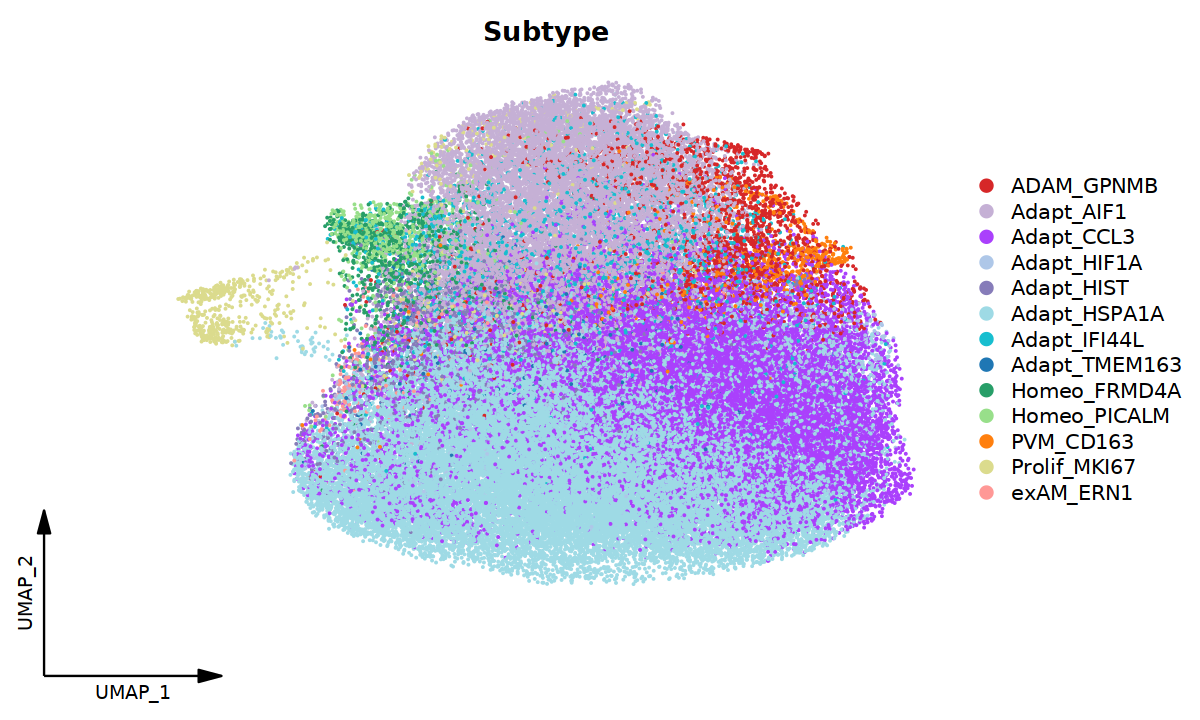

In [11]:

options(repr.plot.width=10, repr.plot.height=6)
p1 <- DimPlot_scCustom(seurat_object = Microglia_only,
                 pt.size = 0.05,
                 colors_use =Project_Colors,
                 group.by ="Subtype" ,
                 reduction="scanvi_umap",
                 figure_plot = TRUE)
p1

Warning message:
"Removed 1 rows containing missing values (`geom_point()`)."


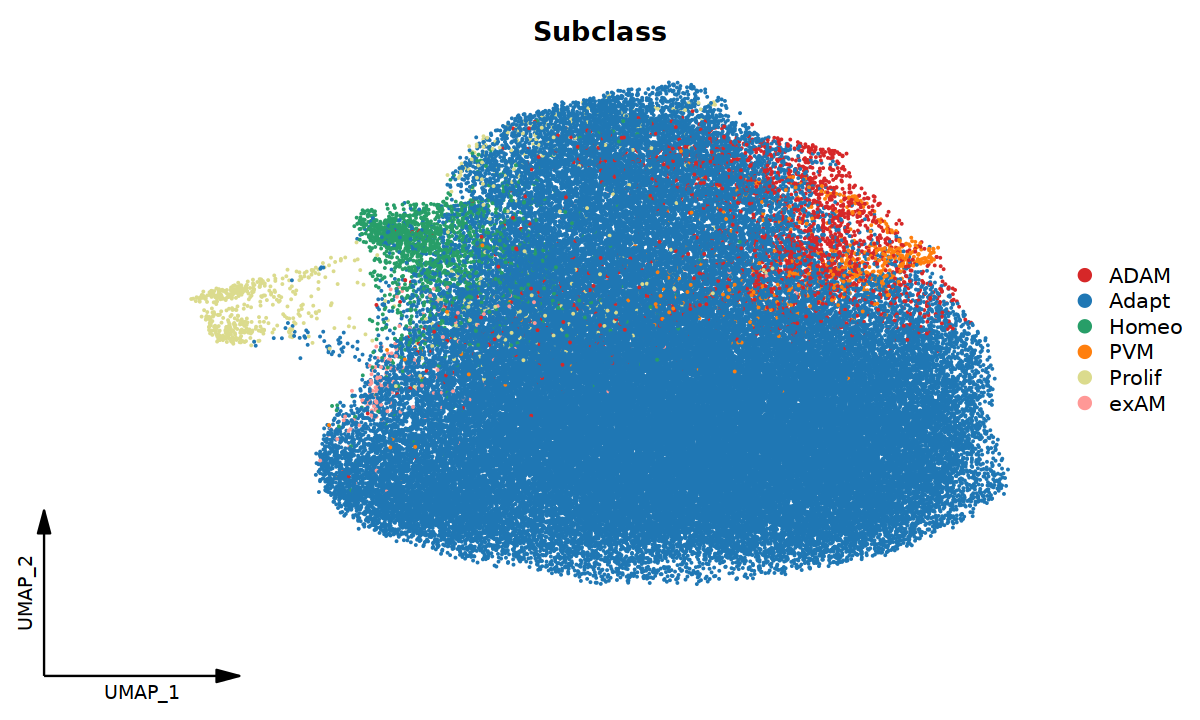

In [12]:
DimPlot_scCustom(seurat_object = Microglia_only,
                 pt.size = 0.05,colors_use =Project_Colors,
                 group.by ="Subclass" ,
                 reduction="scanvi_umap",
                 figure_plot = TRUE)

Warning message:
"Removed 1 rows containing missing values (`geom_point()`)."


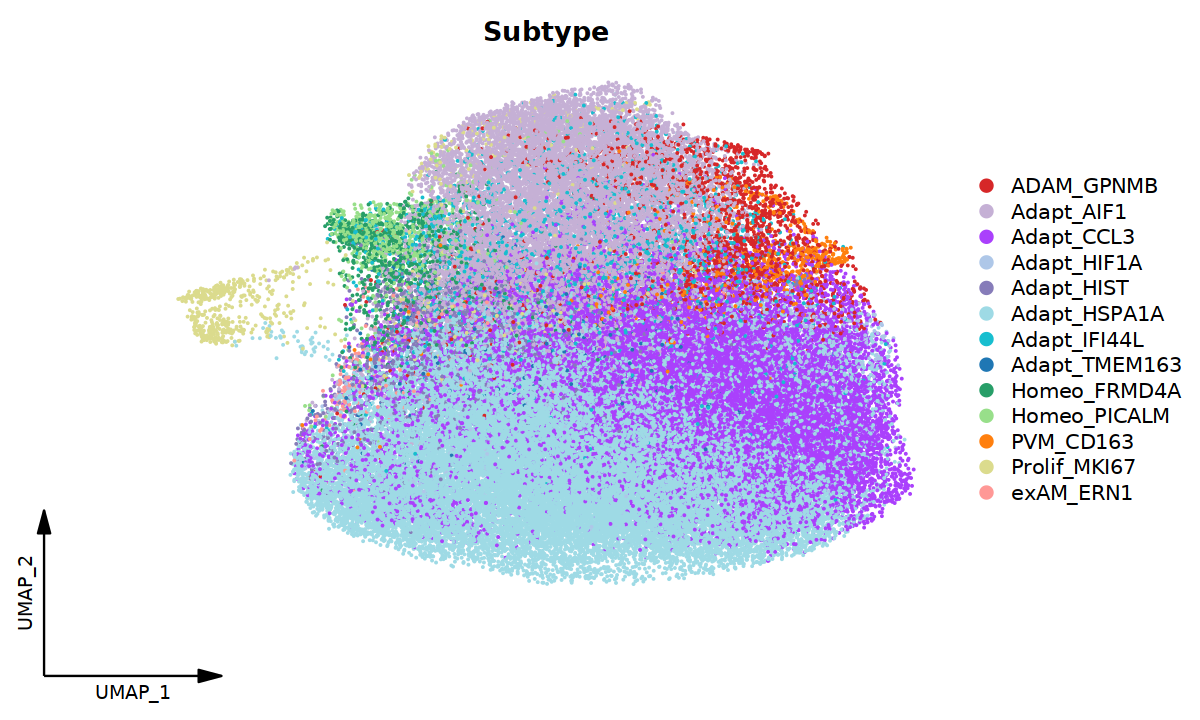

In [13]:
DimPlot_scCustom(seurat_object = Microglia_only,
                 pt.size = 0.05,colors_use =Project_Colors,
                 group.by ="Subtype" ,
                 reduction="scanvi_umap",
                 figure_plot = TRUE)

# TABLE 3

In [14]:
Tables_Dir <- "Tables/"
Table3_df <- Microglia_only@meta.data
readr::write_csv(Table3_df, paste0(Tables_Dir,"3.Table_Myeloid_Metadata.csv"))


In [15]:
Microglia_only[["RNA"]] <- Microglia_only[["RNAv3"]]


Warning message:
"Assay RNA changing from Assay5 to Assay"
Warning message:
"Key 'rnav3_' taken, using 'rna_' instead"


In [16]:
unique(Microglia_only$Subtype)

[1] "Adapt_HSPA1A"  "Adapt_CCL3"    "ADAM_GPNMB"    "Adapt_TMEM163"
 [5] "Prolif_MKI67"  "Adapt_HIF1A"   "PVM_CD163"     "exAM_ERN1"    
 [9] "Adapt_AIF1"    "Adapt_IFI44L"  "Homeo_FRMD4A"  "Adapt_HIST"   
[13] "Homeo_PICALM"

In [17]:
unique(Microglia_only$Subtype)

[1] "Adapt_HSPA1A"  "Adapt_CCL3"    "ADAM_GPNMB"    "Adapt_TMEM163"
 [5] "Prolif_MKI67"  "Adapt_HIF1A"   "PVM_CD163"     "exAM_ERN1"    
 [9] "Adapt_AIF1"    "Adapt_IFI44L"  "Homeo_FRMD4A"  "Adapt_HIST"   
[13] "Homeo_PICALM"

In [18]:
unique(Microglia_only$donor)

[1] "CK-056" "CK-045" "CK-023" "CK-154" "CK-151" "CK-155" "CK-181" "CK-050"
 [9] "CK-165" "CK-008" "CK-166" "CK-057" "CK-123" "CK-051" "CK-157" "CK-038"
[17] "CK-005" "CK-164" "CK-058" "CK-014" "CK-052" "CK-030" "CK-125" "CK-156"
[25] "CK-033" "CK-102" "CK-015" "CK-009" "CK-031" "CK-147"

In [19]:
Metadata <-  Immune@meta.data[!is.na(colnames(Immune@meta.data))]
colnames(Metadata)
Immune@meta.data <- Metadata

[1] "orig.ident"                "nCount_RNA"               
 [3] "nFeature_RNA"              "percent.mt"               
 [5] "percent.ribo"              "is_doublet"               
 [7] "scrublet_score"            "S.Score"                  
 [9] "G2M.Score"                 "Phase"                    
[11] "RNA_snn_res.0.8"           "seurat_clusters"          
[13] "donor"                     "race"                     
[15] "age"                       "etiology"                 
[17] "Viability"                 "sex"                      
[19] "pathology"                 "dx"                       
[21] "DateOfProcedure"           "PMI_mins"                 
[23] "date_processed"            "DfCtB"                    
[25] "NIHSS"                     "PMH"                      
[27] "PHV"                       "PEV"                      
[29] "BL"                        "CL"                       
[31] "TSH"                       "mRS"                      
[33] "Kit"                       "mRS_3class"               
[35] "mRS_binned"                "nUMI"                     
[37] "nGenes"                    "log.nGenes"               
[39] "log.nUMI"                  "barcodeKey"               
[41] "RNA_snn_res.0.4"           "predicted_phase"          
[43] "CC_diff"                   "leiden_labels"            
[45] "doublet_score"             "pred_dbl"                 
[47] "anno"                      "anno_dh"                  
[49] "class"                     "All.Act.Score"            
[51] "Act.Score"                 "Mic.Ident"                
[53] "Cluster1"                  "Cluster2"                 
[55] "Cluster3"                  "Act.Score_Allcells"       
[57] "identity_score"            "Microglial_identity_score"
[59] "CellType"                  "CellPop"                  
[61] "log.genes"                 "nCounts"                  
[63] "log.umis"                  "unintegrated_clusters"    
[65] "harmony_clusters"

In [20]:
Homeo_v <- c('P2RY12', 'CX3CR1')
DAM_v <- c('SPP1', 'B2M', 'TYROBP', 'TREM2', 'MAMDC2', 'CD63', 'GPNMB', 'CCL3')
DIM_v <- c("CCL4", "CD14", "CD83", "CSF2RA", "EIF1", "FOS", "IER2", "JUN", "JUNB", "EGR1", "IL1B", "TNF", "PLAUR", "SAT1", "ZFP36", "BTG2")

Microglia_only <- AddModuleScore(Microglia_only,features = list(Homeo_v),name = 'Homeostatic')
Microglia_only <- AddModuleScore(Microglia_only,features = list(DAM_v),name = 'DAM')
Microglia_only <- AddModuleScore(Microglia_only,features = list(DIM_v),name = 'DIM')

Microglia_only$Homeostatic <- Microglia_only$Homeostatic1
Microglia_only$Homeostatic1 <- NULL

Microglia_only$DAM <- Microglia_only$DAM1
Microglia_only$DAM1 <- NULL

Microglia_only$DIM <- Microglia_only$DIM1
Microglia_only$DIM1 <- NULL



In [ ]:
cols_dot <- c('white','red4')
p1 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = c('P2RY12', 'CX3CR1', 'AIF1', 'TMEM119','MRC1','CD163',DAM_v))

p1 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = Homeo_v)+ 
        ggtitle('Homeo.')+
        theme(plot.title = element_text(hjust = 0.5))

p2 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = c('MRC1','CD163'))+ 
        theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+ggtitle('Macro.')+
        theme(plot.title = element_text(hjust = 0.5))

p3 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = DAM_v)+ 
    theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+
        ggtitle('DAM genes')+
        theme(plot.title = element_text(hjust = 0.5))
p4 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = DIM_v)+ 
    theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+
        ggtitle('DIM genes')+
        theme(plot.title = element_text(hjust = 0.5))

p5 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = c('Homeostatic','DAM','DIM'))+ 
    theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+
        ggtitle('mSC')+
        theme(plot.title = element_text(hjust = 0.5))

options(repr.plot.width=20, repr.plot.height=5)
p1+p2+p3+p4+p5+plot_layout(guides='collect',widths=c(length(Homeo_v),2,length(DAM_v),length(DIM_v),3))

In [22]:
Metadata <- Microglia_only@meta.data


In [ ]:
plot_SANKEY(Metadata,ident.1='Subclass',ident.2='pred_subclass',method='prop')

In [ ]:
plot_SANKEY(Metadata,ident.1='Subtype',ident.2='harmony_clusters',method='Jaccard')

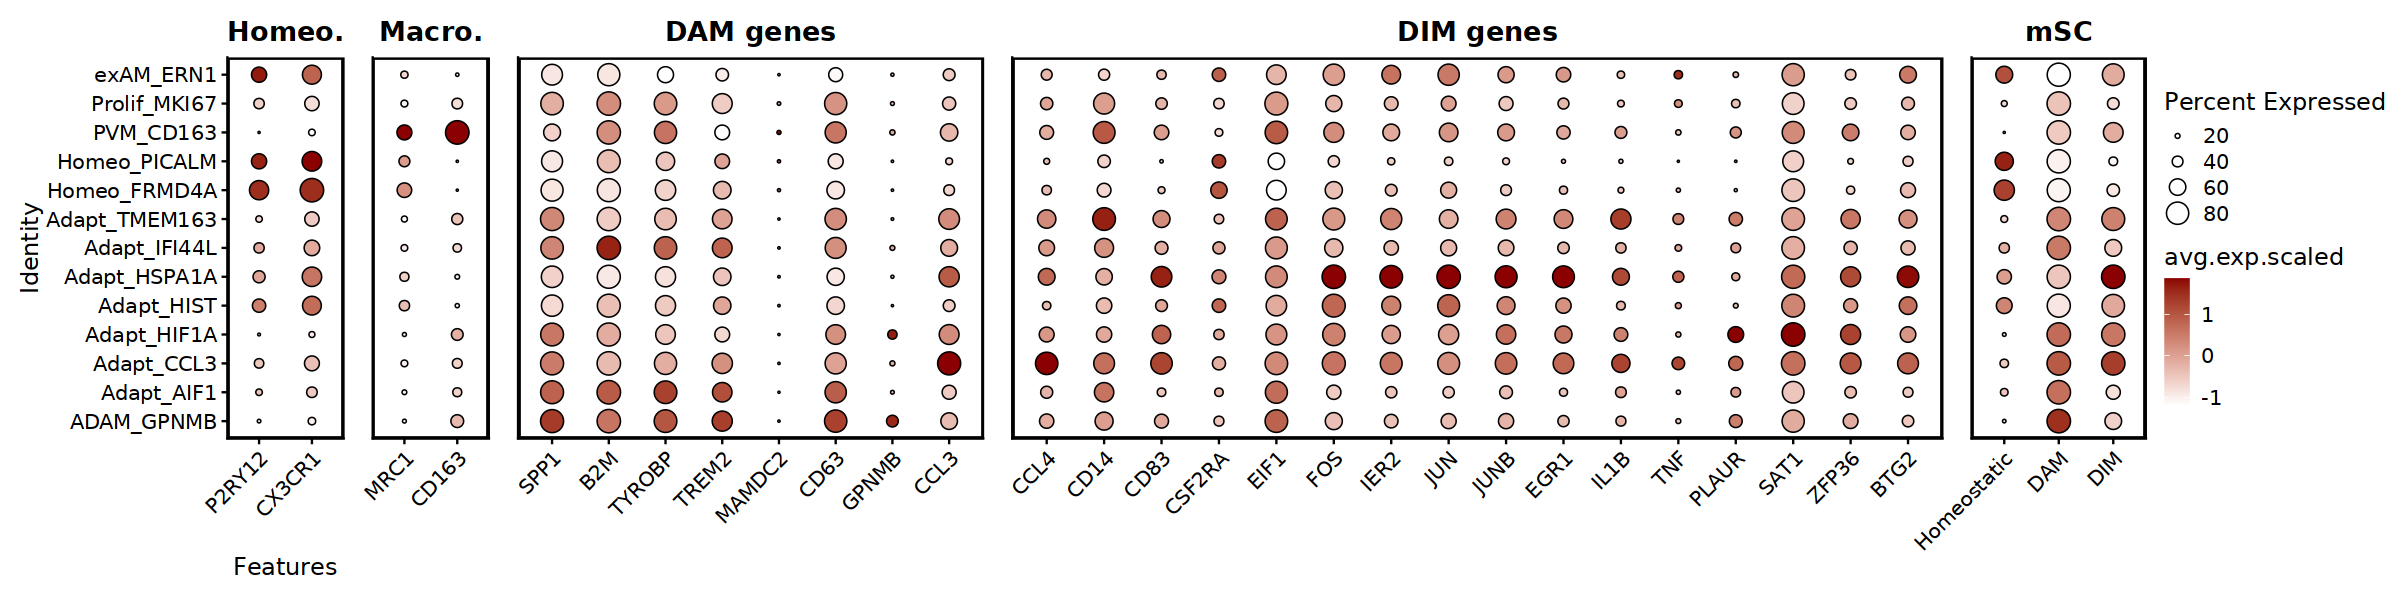

In [28]:
cols_dot <- c('white','red4')
p1 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = c('P2RY12', 'CX3CR1', 'AIF1', 'TMEM119','MRC1','CD163',DAM_v))

p1 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = Homeo_v)+ 
        ggtitle('Homeo.')+
        theme(plot.title = element_text(hjust = 0.5))

p2 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = c('MRC1','CD163'))+ 
        theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+ggtitle('Macro.')+
        theme(plot.title = element_text(hjust = 0.5))

p3 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = DAM_v)+ 
    theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+
        ggtitle('DAM genes')+
        theme(plot.title = element_text(hjust = 0.5))
p4 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = DIM_v)+ 
    theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+
        ggtitle('DIM genes')+
        theme(plot.title = element_text(hjust = 0.5))

p5 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = "Subtype",features = c('Homeostatic','DAM','DIM'))+ 
    theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+
        ggtitle('mSC')+
        theme(plot.title = element_text(hjust = 0.5))

options(repr.plot.width=20, repr.plot.height=5)
p1+p2+p3+p4+p5+plot_layout(guides='collect',widths=c(length(Homeo_v),2,length(DAM_v),length(DIM_v),3))

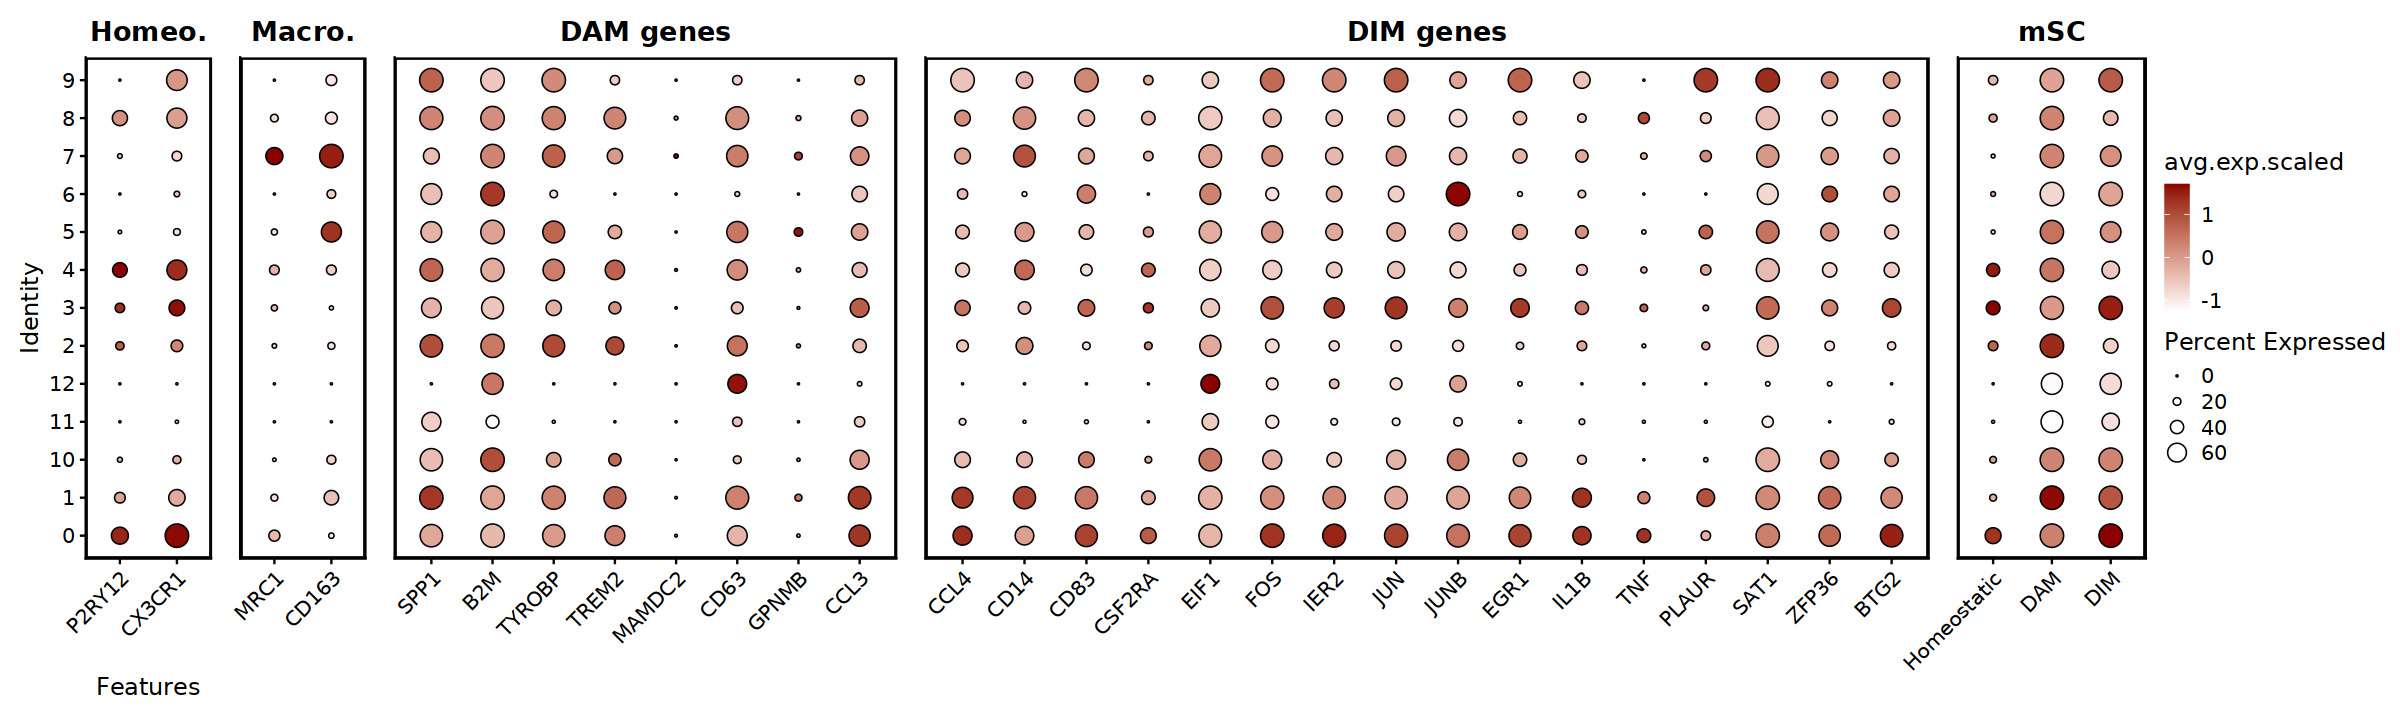

In [29]:
group_by <- 'harmony_clusters'
cols_dot <- c('white','red4')
p1 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = group_by,features = c('P2RY12', 'CX3CR1', 'AIF1', 'TMEM119','MRC1','CD163',DAM_v))

p1 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = group_by,features = Homeo_v)+ 
        ggtitle('Homeo.')+
        theme(plot.title = element_text(hjust = 0.5))

p2 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by =group_by,features = c('MRC1','CD163'))+ 
        theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+ggtitle('Macro.')+
        theme(plot.title = element_text(hjust = 0.5))

p3 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = group_by,features = DAM_v)+ 
    theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+
        ggtitle('DAM genes')+
        theme(plot.title = element_text(hjust = 0.5))
p4 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = group_by,features = DIM_v)+ 
    theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+
        ggtitle('DIM genes')+
        theme(plot.title = element_text(hjust = 0.5))

p5 <- my_DotPlot(Microglia_only,cols=cols_dot,group.by = group_by,features = c('Homeostatic','DAM','DIM'))+ 
    theme(
        axis.title.x=element_blank(),
        axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())+NoLegend()+
        ggtitle('mSC')+
        theme(plot.title = element_text(hjust = 0.5))

options(repr.plot.width=20, repr.plot.height=6)
p1+p2+p3+p4+p5+plot_layout(guides='collect',widths=c(length(Homeo_v),2,length(DAM_v),length(DIM_v),3))

In [30]:
library(crumblr)
mat <- as.matrix(Microglia_only@assays$RNA@counts)
dim(mat)
sce <- SingleCellExperiment(
  assays = list(counts = mat),
  colData = Microglia_only@meta.data
)

Warning message:
"no DISPLAY variable so Tk is not available"
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 10.9 GiB"


[1] 17500 83519

In [31]:
sce$Subtype_Names <-  gsub("Adapt_|Homeo_|PVM_|ADAM_|Prolif_|exAM_", "",sce$Subtype)
unique(sce$Subtype_Names)

[1] "HSPA1A"  "CCL3"    "GPNMB"   "TMEM163" "MKI67"   "HIF1A"   "CD163"  
 [8] "ERN1"    "AIF1"    "IFI44L"  "FRMD4A"  "HIST"    "PICALM"

In [32]:
group_by_cl <- "Subtype_Names"
library(dreamlet)
pbObj_subtype <- aggregateToPseudoBulk(sce,
    assay = "counts",
    cluster_id = group_by_cl,
    sample_id = "donor",
    BPPARAM = SnowParam(5, progressbar=TRUE))

# CrumblR

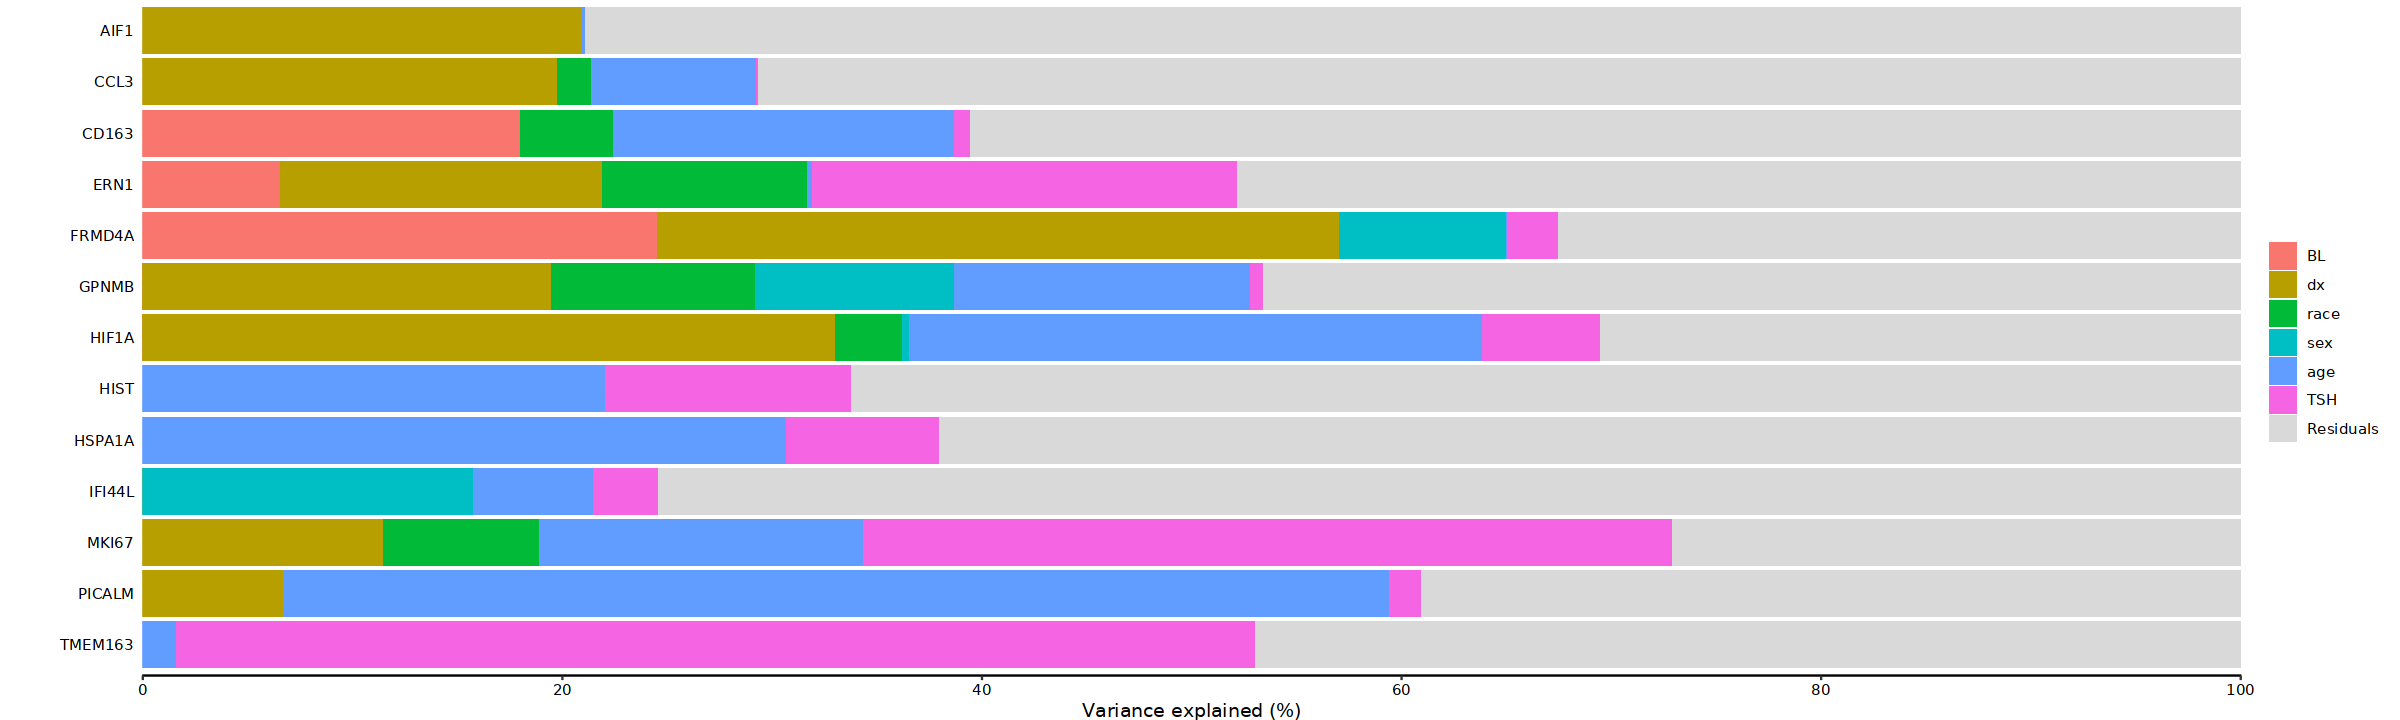

In [34]:
cobj = crumblr(cellCounts(pbObj_subtype))
# Partition variance into components for Subject (i.e. ind)
#   and stimulation status, and residual variation
vp = fitExtractVarPartModel( cobj, ~ (1|race) +(1|sex)+(1|BL)+(1|dx)+age+TSH, colData(pbObj_subtype))

# Plot variance fractions
plotPercentBars(vp)

png 
  2

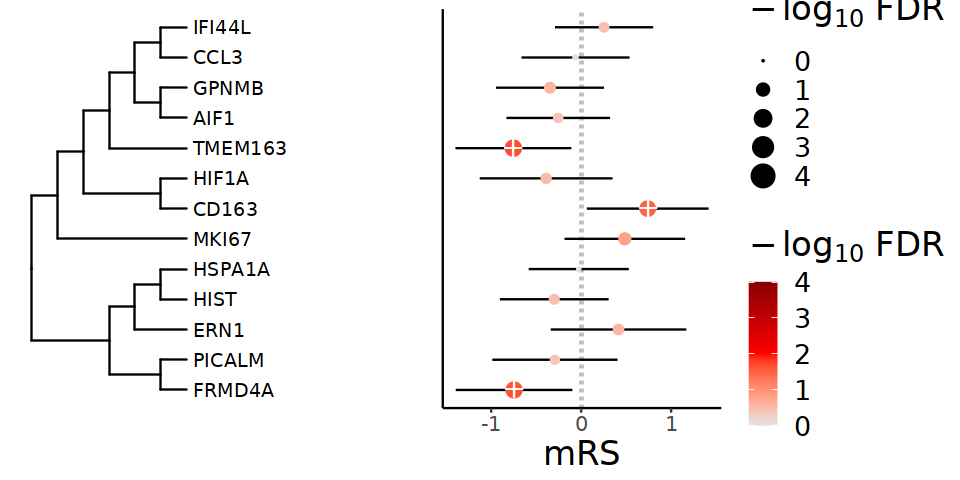

In [51]:
form = ~ (1|race) +(1|sex)+(1|BL)+(1|dx)+age+TSH+mRS_binned +0
L = makeContrastsDream(form, colData(pbObj_subtype),
                       contrasts=c(mRS_contrast="mRS_binnedB -mRS_binnedG"))
fit = dream(cobj, form, colData(pbObj_subtype), L=L)
fit = eBayes(fit)                                                    
res.mRS = topTable(fit, coef="mRS_contrast", 
                   number=Inf, 
                   sort.by="none")
res.mRS$assay <- rownames(res.mRS )
res.age = dh_meta_analysis(list(res.mRS))
hc = buildClusterTreeFromPB(pbObj_subtype)
fig.tree = dh_plotTree(ape::as.phylo(hc),
                       xmax.scale=2.2) + 
                theme(legend.position="bottom")
fig.es1<- dh_plotCoef(res.age, coef='mRS', fig.tree, ylab='mRS')
options(repr.plot.width=8, repr.plot.height=4)
fig.es1 %>% insert_left(fig.tree, width=1.4) 



pdf('SupFigures/SFigure2C.pdf',width=8, height=4)
# Display the heatmap plot
fig.es1 %>% insert_left(fig.tree, width=1.4) 
dev.off()

In [36]:
my_vector <- c(
    'AIF1',
    "TMSB10",
    'RPLP2',
    'FTL',
    'S100A9',
    'CCL3',
    'CCL4',
    'CCL3L1',
    'CCL4L2',
    'HIF1A',
    'CREM',
    'TNFRSF1B',
    'SIPA1L1',
    'FAM110B',
  "H1-3",
  "H2AC8", "H2BC4",
  "H2BC7",
  "HSPA1A",
  "HSPH1",
  "HSP90AA1",
  "DNAJA4",
  "IFIT1",
  "IFIT2",
  "IFIT3",
  "IF144",
  "TMEM163", "NCK2",
  "SH3RF3",
  "PTPN2", "LIMK2",
  "FRMD4A",
  "P2RY12", "RASGEF1C",
  "CX3CR1",
  "NAV2", "CECR2",
  "PICALM",
  'OXR1','WNT2B1',
  "ELMO1",
  "CD163", 
  "CSGALNACT1",
  "SELENO",
  "GPNMB",
  "ERNI",
  "CSKMT",
  "PTPRG",
  "SAMD4A",
  "MKI67",
  "HELLS",
    'CLSPN',
    'CENPK',
    'ERN1',
    'CSKMT',
    'PLK2'
)


In [37]:
ToPlot <- AverageExpression(Microglia_only,group.by = 'Subtype',assay='RNA',slot = 'data',features =my_vector)$RNA

Warning message:
"`invoke()` is deprecated as of rlang 0.4.0.
Please use `exec()` or `inject()` instead.
This warning is displayed once every 8 hours."
Warning message:
"The following 11 features were not found in the RNA assay: RPLP2, H1-3, H2AC8, H2BC4, H2BC7, IF144, OXR1, WNT2B1, SELENO, ERNI, CSKMT"


png 
  2

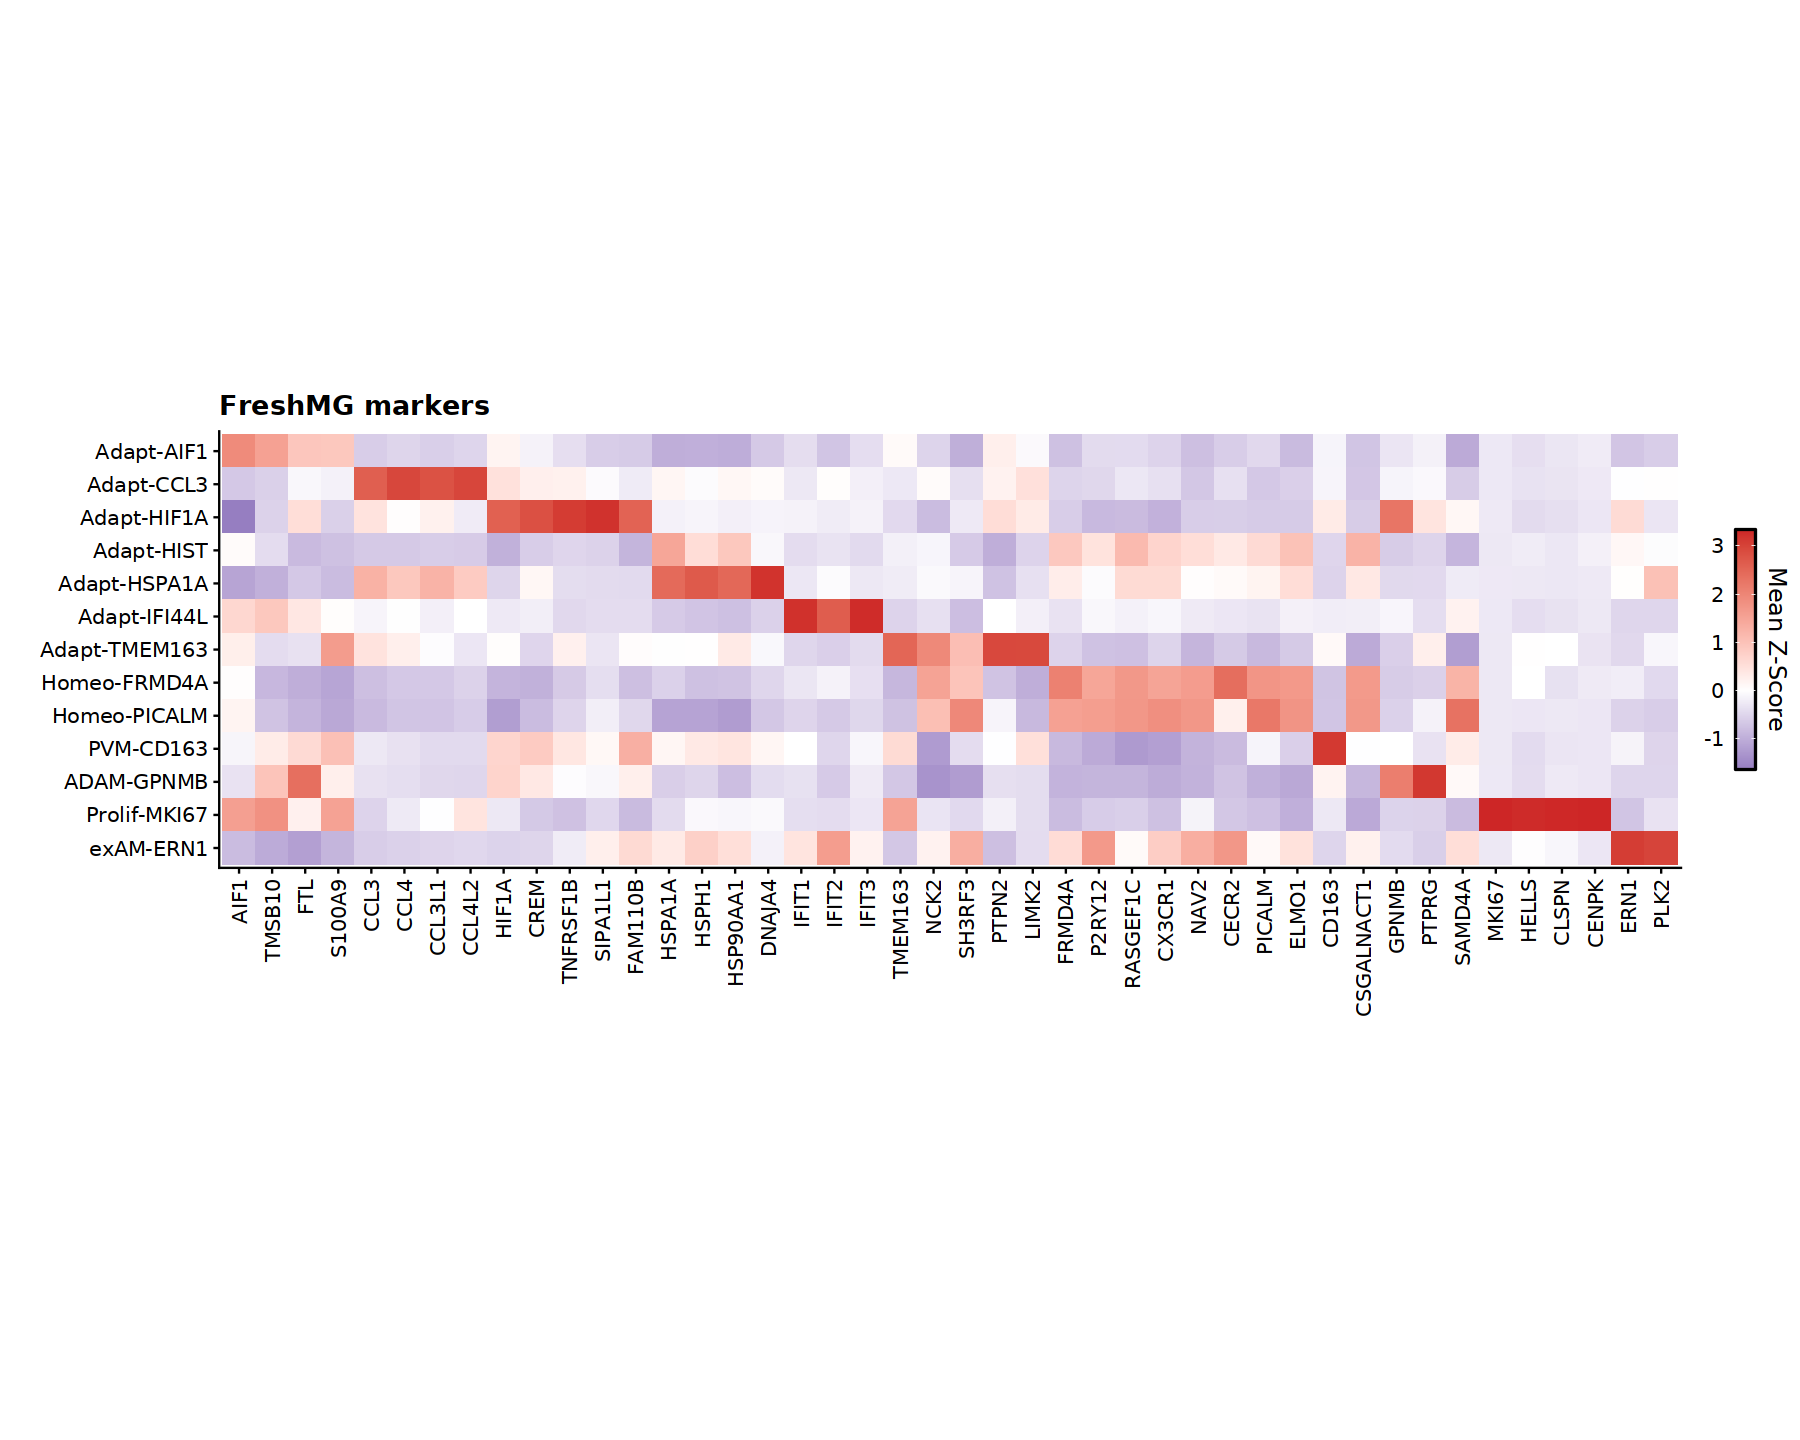

In [49]:
options(repr.plot.width=15, repr.plot.height=12)
# Load the necessary libraries
library(ggplot2)
library(reshape2)
library(ggplot2)

z_scores <- scale(t(ToPlot))


z_scores <- z_scores[c('Adapt-AIF1','Adapt-CCL3',
'Adapt-HIF1A',
'Adapt-HIST',
'Adapt-HSPA1A','Adapt-IFI44L','Adapt-TMEM163',
'Homeo-FRMD4A','Homeo-PICALM',
'PVM-CD163','ADAM-GPNMB',
'Prolif-MKI67','exAM-ERN1'),]

# Convert the z-scores matrix to a long format for ggplot
z_scores_melted <- melt(z_scores)
# Reverse the order of rows
z_scores_melted$Var1 <- factor(z_scores_melted$Var1, levels = rev(levels(z_scores_melted$Var1)))

# Create the heatmap with ggplot2
heatmap_plot <- ggplot(data = z_scores_melted, aes(x = Var2, y = Var1, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(
    low = 'navy',
  mid = "white",
  high = 'firebrick3',
        midpoint = 0,
      name = "Mean Z-Score",  # Legend title
    guide = guide_colorbar(
        frame.linewidth = 0.7,
      frame.colour = "black",  # Color bar outline color
      barwidth = 0.8,  # Color bar width
      barheight = 10 , # Color bar height,
      title.position = 'right', #Place legend title on top of the color bar
     title.hjust = 0.5,  # Center the legend title horizontally
      title.vjust = 0.5,  # Center the legend title vertically
      label.position = "left"  # Place labels to the left of the color bar
 
    )
  ) +
  labs(
    x = "Samples",
    y = "Genes",
    title = "FreshMG markers"
  ) +
  theme_cowplot() +ylab("")+xlab("")+
  theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust=0.5),
    legend.text = element_text(angle = 0, hjust = 1, vjust = 0.5), # Rotate the legend title
    legend.title = element_text(angle = -90, hjust = 0.5, vjust = 0.5) # Rotate the legend title)
)
# Display the heatmap plot
heatmap_plot+coord_equal()


pdf('SupFigures/SFigure2B.pdf',width=15, height=12)
# Display the heatmap plot
heatmap_plot+coord_equal()
dev.off()

In [39]:
saveCRDS(Microglia_only,'/sc/arion/projects/CommonMind/kyriad02/ICH_Stroke/result/Cortex/5.FreshMG_Mapping/Myeloid_Pred_ADAM.rds.zstd',filter='zstd')


In [40]:
sce <- as.SingleCellExperiment(Microglia_only)


In [41]:
#=============== Aggregate pseudobulk =======================
pbObj <- aggregateToPseudoBulk(sce,
    assay = "counts",
    cluster_id = "Subtype",
    sample_id = "donor",
    BPPARAM = SnowParam(30, progressbar=TRUE))
# -------------------------------------------------------------
# -------------------------------------------------------------


In [ ]:
#=============== Preprocess pseudobulk ========================
#=============== Preprocess pseudobulk ========================
# age+ 
# Normalize and apply voom/voomWithDreamWeights
res.proc = processAssays(pbObj, ~ race+dx +BL+TSH+age +mRS_binned, 
    min.count=1,
    BPPARAM = SnowParam(threads, progressbar=TRUE))

# the resulting object of class dreamletProcessedData stores 
# normalized data and other information
res.proc
# view details of dropping samples
details(res.proc)

In [ ]:
vp.lst <- fitVarPart(res.proc, ~ race +dx+sex + BL+TSH+ age +mRS_binned)

In [ ]:
# Summarize variance fractions genome-wide for each cell type
plotVarPart(vp.lst, label.angle = 60,ncol=5)

In [ ]:
plotVoom(res.proc, ncol=4)

In [ ]:
res.dream_mRS = dreamlet(res.proc, ~ (1|race)+ (1|dx)+ (1|BL)+age +mRS_binned+0,
                contrasts=c(Diff_B_vs_G="mRS_binnedB-mRS_binnedG"),
                BPPARAM = SnowParam(40, progressbar=TRUE))

In [54]:
Vlcano_df <- as.data.frame(topTable(res.dream_mRS,p.value = 1,lfc = 0,number = 100000000, coef = "Diff_B_vs_G" ))
Vlcano_df <- Vlcano_df[order(Vlcano_df$adj.P.Val),]
colnames(Vlcano_df)[2]<- "gene.name"
# add a column of NAs
Vlcano_df$diffexpressed <- "NO"
Vlcano_df$diffexpressed <- "NS"

In [ ]:
library(ggpubr)
library(ggrepel)
plotlist <- lapply(unique(Vlcano_df$assay),function(cellType){
    my_Vlc_plot(Vlcano_df,x_lim,cellType)
})
options(repr.plot.width=20, repr.plot.height=15)
gridExtra::grid.arrange(grobs = plotlist,ncol=5)


In [52]:
Subtype_dreamlet_mRS <- '2023_12_07_MG_Subtype_ADAM_Dreamlet_mRS_race_sex_BL_TSH_age.rds.zstd'
res.dream_mRS  <- readCRDS( Subtype_dreamlet_mRS) 

In [ ]:
DEGs_file <- as.data.frame(topTable(res.dream_mRS,
    p.value = 1,lfc = 0,number = 100000000,
    coef = "Diff_B_vs_G" ))
DEGs_file <- DEGs_file[DEGs_file$assay %in% unique(Vlcano_df$assay),]
#DEGs_file <- DEGs_file[DEGs_file$assay %in% subtype_keep,]

loaded_DEGs <-Vlcano_df
colnames(Vlcano_df)[2]<- "gene.name"
loaded_DEGs$cluster <- ifelse(loaded_DEGs$logFC>0,'Bad','Good')
loaded_DEGs$cluster <- paste0(loaded_DEGs$cluster,"_",loaded_DEGs$assay)
loaded_DEGs$gene < loaded_DEGs$gene.name
background <- unique(DEGs_file$ID)
DEGs_file <- DEGs_file %>% group_by(ID) %>% mutate(pos_avgLFC=mean(logFC))
DEGs_file <- DEGs_file %>% group_by(ID) %>% mutate(avg_LFC=sum(logFC)/length(unique(DEGs_file$assay)))


png 
  2

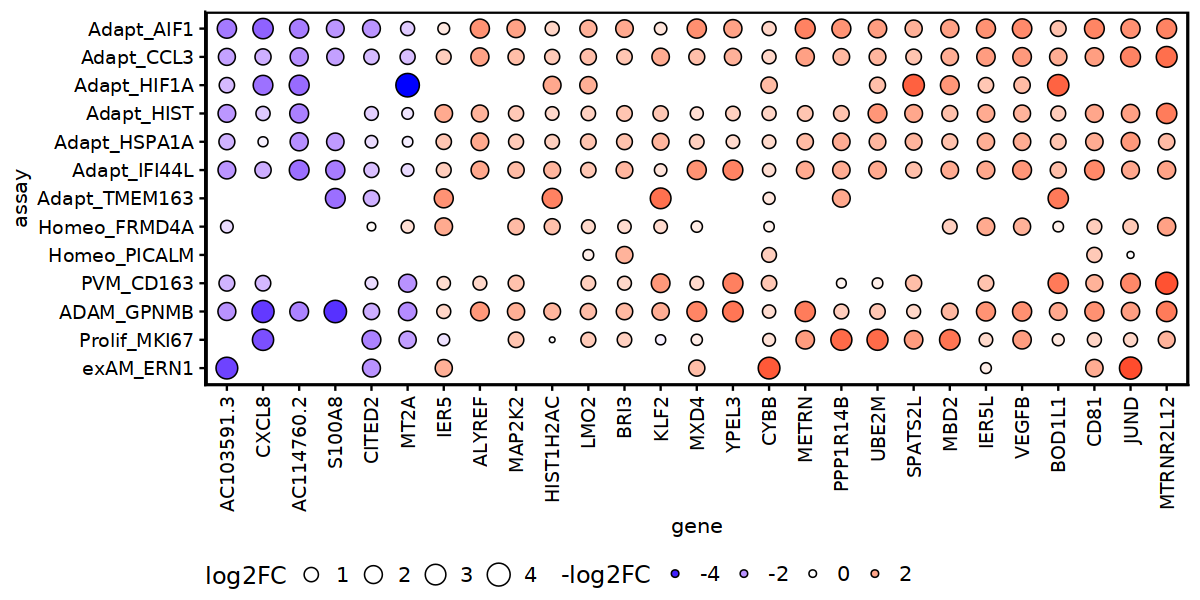

In [58]:
sign_DEGS_df <- DEGs_file[DEGs_file$adj.P.Val <0.05 & abs(DEGs_file$avg_LFC) > 1,]
data.plot <- DEGs_file[DEGs_file$ID %in% unique(as.factor(sign_DEGS_df$ID)),]
data.plot <- data.plot %>% na.omit()
data.plot<- data.plot[order(data.plot$avg_LFC),]
data.plot$gene <- factor(as.vector(data.plot$ID),levels= unique(as.vector(data.plot$ID)))
cols=c("blue","red")


 
data.plot$assay <- factor(data.plot$assay,levels=rev(c('Adapt_AIF1','Adapt_CCL3',
'Adapt_HIF1A',
'Adapt_HIST',
'Adapt_HSPA1A','Adapt_IFI44L','Adapt_TMEM163',
'Homeo_FRMD4A','Homeo_PICALM',
'PVM_CD163','ADAM_GPNMB',
'Prolif_MKI67','exAM_ERN1')))



plot <- ggplot(data = data.plot, aes(x = gene, y = assay,size = abs(logFC),fill = logFC)) +
    geom_point(shape = 21, colour = "black")+
    theme(axis.title.x = element_blank(), axis.title.y = element_blank()) +
    guides(size = guide_legend(title = 'log2FC')) +
    guides(fill = guide_legend(title = '-log2FC')) +
    theme_cowplot()+
    theme(panel.border = element_rect(colour = "black", fill=NA, size=1))+
    scale_fill_gradient2(low = cols[1],mid = 'white', high = cols[2])+
        theme(plot.title = element_text(hjust = 0.5),
             axis.text = element_text(size = 11),  # Adjust font size for axis ticks
           axis.title = element_text(size = 12),
             axis.text.x = element_text(angle = 90,vjust=0.5, hjust = 1))+ theme(legend.position = "bottom")


options(repr.plot.width=10, repr.plot.height=5)
plot

pdf('SupFigures/SFigure2D.pdf',width=10, height=5)
# Display the heatmap plot
plot
dev.off()

In [ ]:
# Load required libraries
library(clusterProfiler)
library(org.Hs.eg.db)
DEGs_file$cluster <- ifelse(DEGs_file$avg_LFC>0,'Poor','Good')
DEGs_file$absLFC <- abs(DEGs_file$avg_LFC)
DEGs_file$gene <- DEGs_file$ID
# Extract genes with p-value < 0.05 and adjusted fold change > 1.5
significant_genes <- DEGs_file[DEGs_file$adj.P.Val <= 0.05 & DEGs_file$absLFC >= 0.5,]
BP_formula_res <- compareCluster(gene~cluster+assay,
                                 data=significant_genes, 
                                 fun = "enrichGO", 
                                 ont="MF",
                                 keyType='SYMBOL',
                                 OrgDb = org.Hs.eg.db,
                                 pvalueCutoff = 0.05)


,Cluster,cluster,assay,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,fun
,<fct>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
1,Good.ADAM_GPNMB (66),Good,ADAM_GPNMB,GO:0008009,chemokine activity,0.06060606,49/18369,2.851582e-05,0.0061023850,0.0051028305,CXCL8/CCL2/CCL3/CCL3L1,4,BP
2,Good.ADAM_GPNMB (66),Good,ADAM_GPNMB,GO:0042379,chemokine receptor binding,0.06060606,74/18369,1.447746e-04,0.0154908853,0.0129535194,CXCL8/CCL2/CCL3/CCL3L1,4,BP
3,Good.ADAM_GPNMB (66),Good,ADAM_GPNMB,GO:0050786,RAGE receptor binding,0.03030303,10/18369,5.616285e-04,0.0400628365,0.0335006503,S100A8/S100A9,2,BP
5,Good.ADAM_GPNMB (66),Good,ADAM_GPNMB,GO:0035325,Toll-like receptor binding,0.03030303,13/18369,9.667362e-04,0.0413763103,0.0345989806,S100A8/S100A9,2,BP
8,Good.ADAM_GPNMB (66),Good,ADAM_GPNMB,GO:0140297,DNA-binding transcription factor binding,0.10606061,478/18369,1.601064e-03,0.0428284736,0.0358132834,ID2/MYC/KLF4/CITED2/EGR2/TRIB1/ATF4,7,BP
11,Good.Adapt_AIF1 (75),Good,Adapt_AIF1,GO:0140297,DNA-binding transcription factor binding,0.10666667,478/18369,7.265311e-04,0.0479910614,0.0398817685,CITED2/ATF4/KLF4/EGR2/ID2/HMGB2/MYC/TRIB1,8,BP
12,Good.Adapt_AIF1 (75),Good,Adapt_AIF1,GO:0019210,kinase inhibitor activity,0.04000000,44/18369,7.676825e-04,0.0479910614,0.0398817685,HEXIM1/RHOH/TRIB1,3,BP
15,Good.Adapt_AIF1 (75),Good,Adapt_AIF1,GO:0008009,chemokine activity,0.04000000,49/18369,1.052436e-03,0.0479910614,0.0398817685,CXCL8/CCL3/CCL3L1,3,BP
16,Good.Adapt_HIF1A (7),Good,Adapt_HIF1A,GO:0004713,protein tyrosine kinase activity,0.28571429,137/18369,1.131559e-03,0.0396045576,0.0178667177,ABL2/MAP2K1,2,BP


Warning message:
"Removed 6 rows containing missing values (`geom_text()`)."


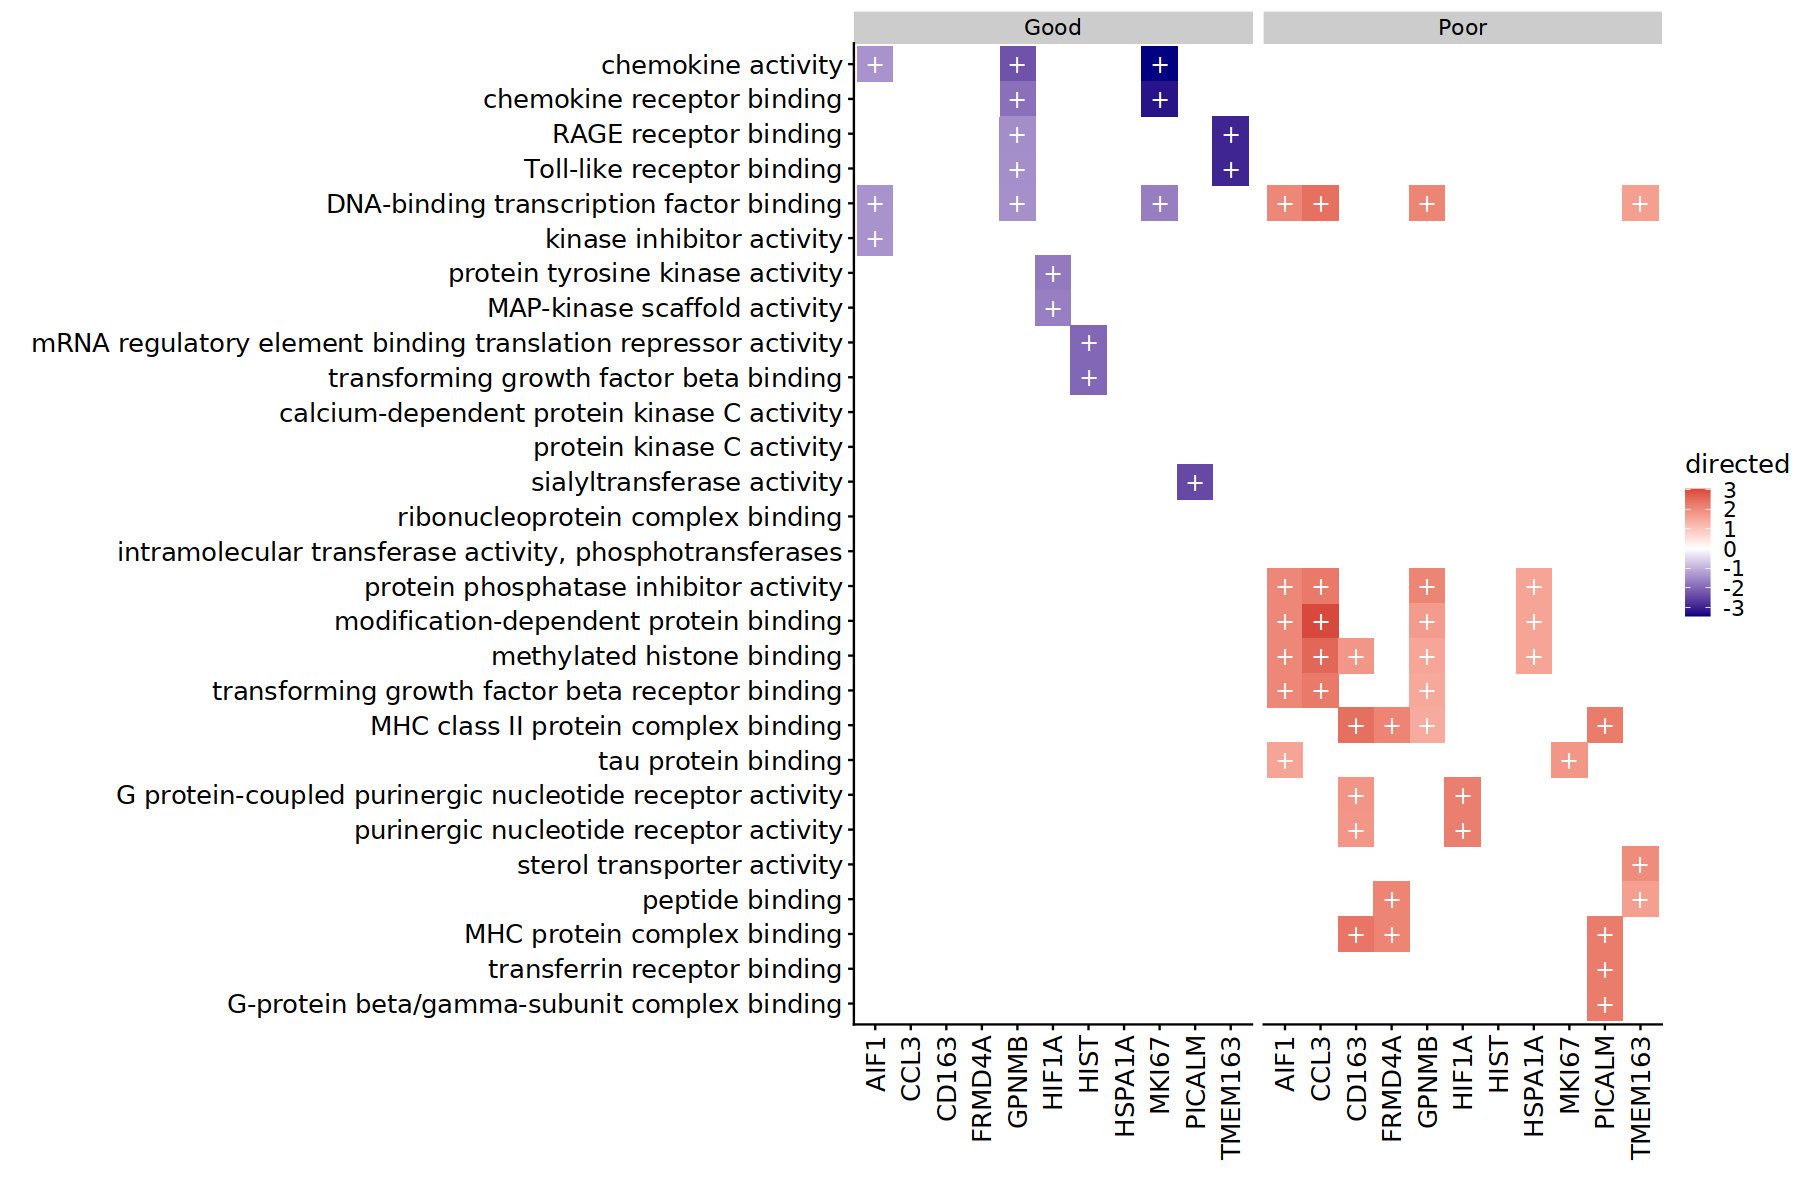

In [60]:
options(repr.plot.width=15, repr.plot.height=10)
BP_top <- dotplot(BP_formula_res,showCategory = 2)$data
BP_top$fun <- 'BP'
BP_top
BP_top$Significant <- ifelse(BP_top$qvalue<0.05,'+',"")
library(cowplot)
library(Seurat)

BP_top$Log10Qval <- -log10(BP_top$qvalue)
BP_top$directed <- BP_top$Log10Qval
multiplier <- ifelse(BP_top$cluster=='Good',-1,1)
BP_top$directed <- BP_top$Log10Qval * multiplier
BP_top$assay <- gsub("Adapt_|Homeo_|PVM_|Prolif_|ADAM_|exAM_", "", BP_top$assay)

p <- ggplot(BP_top,aes(x=assay,
                        y=Description,
                        color = directed,
                        fill = directed,
#                         size=GeneRatio,
                        label=Significant))+
  geom_tile()+
  geom_text(alpha=1,size=5,colour = "white")+
  theme_cowplot() +
  RotatedAxis()+
  theme(text = element_text(size = 15),
        axis.text.x = element_text(size = 15,angle = 90,vjust=0.5,hjust = 1),
        axis.text.y = element_text(size = 15))+
  theme(plot.title = element_text(hjust = 0.5))+facet_wrap(~cluster)+
  scale_fill_gradient2(low = 'navy',mid = 'white', high = 'firebrick3',na.value = 'white')+
  scale_color_gradient2(low = 'navy',mid = 'white', high = 'firebrick3',na.value = 'white')+xlab("")+ylab("")
p

In [61]:
pdf('SupFigures/SFigure2E.pdf',width=15, height=10)
# Display the heatmap plot
p
dev.off()

Warning message:
"Removed 6 rows containing missing values (`geom_text()`)."


png 
  2

In [ ]:
DEGs_file <- as.data.frame(topTable(res.dream_mRS,
    p.value = 1,lfc = 0,number = 100000000,
    coef = "Diff_B_vs_G" ))

In [ ]:
# Load required libraries
library(clusterProfiler)
# Extract genes with p-value < 0.05 and adjusted fold change > 1.5
sign_DEGS_df <- DEGs_file[DEGs_file$adj.P.Val <0.05 & abs(DEGs_file$avg_LFC) > 1,]

significant_genes <- DEGs[DEGs$p_val_adj <= 0.05 & DEGs$avg_log2FC >= 0.5,]
# Convert gene symbols to entrez IDs
gene_ids <- bitr(significant_genes$gene, fromType = "SYMBOL", toType = c("SYMBOL","ENTREZID","ENSEMBL"), OrgDb = org.Hs.eg.db)
gene_ids <- gene_ids[complete.cases(gene_ids), ]
# Assuming your dataframe is named 'your_dataframe' and the column is named 'column_name'
gene_ids <- gene_ids[!duplicated(gene_ids$SYMBOL), ]
# Merge the dataframes based on the 'gene' column
merged_df <- merge(significant_genes, gene_ids[, c("SYMBOL", "ENTREZID", "ENSEMBL")], by.x = "gene", by.y = "SYMBOL", all.x = TRUE)
rownames(merged_df) <- merged_df$gene
merged_df <- merged_df[significant_genes$gene,]
dim(merged_df)
BP_formula_res <- compareCluster(gene~cluster,
                                 data=merged_df, 
                                 fun = "enrichGO", 
                                 ont="BP",
                                 keyType='SYMBOL',
                                 OrgDb = org.Hs.eg.db,
                                 pvalueCutoff = 0.05)

Warning message in dream(cobj, form, colData(pbObj_subtype), L = L):
"Model failed for 1 responses.
  See errors with attr(., 'errors')"


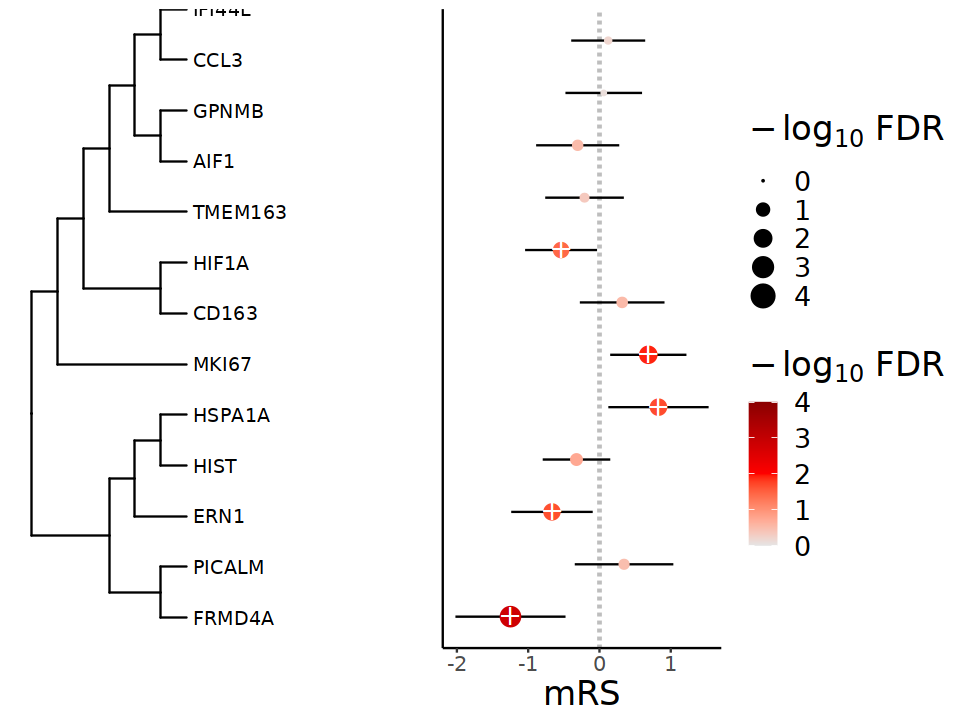

In [63]:

form = ~ (1|race) +(1|sex)+(1|BL)+(1|dx)+TSH+mRS_binned +0
L = makeContrastsDream(form, colData(pbObj_subtype),
                       contrasts=c(mRS_contrast="mRS_binnedB -mRS_binnedG"))
fit = dream(cobj, form, colData(pbObj_subtype), L=L)
fit = eBayes(fit)                                                    
res.mRS = topTable(fit, coef="mRS_contrast", 
                   number=Inf, 
                   sort.by="none")
res.mRS$assay <- rownames(res.mRS )
res.age = dh_meta_analysis(list(res.mRS))
hc = buildClusterTreeFromPB(pbObj_subtype)
fig.tree = dh_plotTree(ape::as.phylo(hc),
                       xmax.scale=2.2) + 
                theme(legend.position="bottom")
fig.es1<- dh_plotCoef(res.age, coef='mRS', fig.tree, ylab='mRS')
options(repr.plot.width=8, repr.plot.height=6)
fig.es1 %>% insert_left(fig.tree, width=1.4) 

In [69]:
saveCRDS(Microglia_only,'5.FreshMG_Mapping/Myeloid_Pred.rds.zstd',filter='zstd')
